In [12]:
import math

import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy
from scipy.spatial.distance import jensenshannon

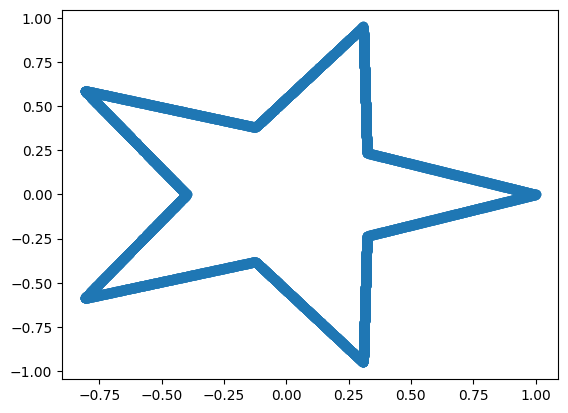

In [23]:
def generate_star(n_spikes=5, inner_radius=0.4, outer_radius=1.0, n_samples=1000, center=(0, 0)):
    angle_step = np.pi / n_spikes

    vertices = []
    for i in range(2 * n_spikes):
        angle = i * angle_step
        radius = outer_radius if i % 2 == 0 else inner_radius

        x = radius * np.cos(angle) + center[0]
        y = radius * np.sin(angle) + center[1]
        vertices.append([x, y])

    vertices.append(vertices[0])
    vertices = np.array(vertices)

    pts = []
    for i in range(len(vertices) - 1):
        for t in np.linspace(0, 1, n_samples // (len(vertices) - 1)):
            pts.append((1 - t) * vertices[i] + t * vertices[i + 1])

    return np.array(pts)


s = generate_star(n_samples=5000)

plt.scatter(s[:, 0], s[:, 1])
plt.show()

In [14]:
class Config:
    def __init__(self):
        self.data_samples = 5000
        self.batch_size = 256
        self.lr = 1e-3
        self.epochs = 500
        self.hidden_dim = 128
        self.num_timesteps = 100

        self.beta_min = 0.1
        self.beta_max = 20.0

In [15]:
class ScoreModel(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.time_embed = nn.Sequential(
            nn.Linear(1, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.hidden_dim)
        )

        self.net = nn.Sequential(
            nn.Linear(2 + config.hidden_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, 2)
        )

    def forward(self, x, t):
        t_emb = self.time_embed(t)
        x_in = torch.cat([x, t_emb], dim=1)
        return self.net(x_in)

In [16]:
def beta_linear(t, config):
    return config.beta_min + t * (config.beta_max - config.beta_min)


def beta_cosine(t):
    s = 0.008
    theta = (t + s) / (1 + s) * math.pi / 2

    alpha = torch.cos(theta) ** 2
    dtheta = math.pi / (2 * (1 + s))

    dalpha = -2 * torch.cos(theta) * torch.sin(theta) * dtheta
    beta = -dalpha / (alpha + 1e-8)

    return torch.clamp(beta, min=1e-5, max=50.0)

In [17]:
def marginal_std(t, config, beta_fn):
    if beta_fn == beta_linear:
        log_mean = -0.25 * (config.beta_min * t +
                           0.5 * (config.beta_max - config.beta_min) * t**2)
        return torch.exp(log_mean)

    else:
        s = 0.008
        alpha = torch.cos((t + s) / (1 + s) * math.pi / 2) ** 2
        alpha0 = math.cos(s / (1 + s) * math.pi / 2) ** 2
        return torch.sqrt(alpha / alpha0)


In [18]:
def w_const(t, *_):
    return torch.ones_like(t)


def w_linear(t, *_):
    return 0.1 + t


def w_exp(t, *_):
    return torch.exp(2 * t)

In [19]:
class VPSDETrainer:
    def __init__(self, config, beta_fn, weight_fn, name, data):
        self.config = config
        self.beta_fn = beta_fn
        self.weight_fn = weight_fn
        self.name = name

        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        data = torch.tensor(data, dtype=torch.float32)
        self.loader = DataLoader(TensorDataset(data),
                                 batch_size=config.batch_size,
                                 shuffle=True)

        self.model = ScoreModel(config).to(self.device)
        self.opt = optim.Adam(self.model.parameters(), lr=config.lr)

        self.losses = []

    def train_epoch(self):
        self.model.train()
        total = 0

        for (x,) in self.loader:
            x = x.to(self.device)

            t = torch.rand(x.shape[0], 1, device=self.device)
            std = marginal_std(t, self.config, self.beta_fn)

            z = torch.randn_like(x)
            x_t = std * x + torch.sqrt(1 - std**2 + 1e-8) * z

            pred = self.model(x_t, t)

            w = self.weight_fn(t, self.config, self.beta_fn)
            loss = (w * (pred - z) ** 2).mean()

            self.opt.zero_grad()
            loss.backward()
            self.opt.step()

            total += loss.item() * x.shape[0]

        return total / len(self.loader.dataset)

    def run(self):
        print(f"\nTraining {self.name}")
        for i in range(self.config.epochs):
            loss = self.train_epoch()
            self.losses.append(loss)

            if i % 100 == 0:
                print(f"Epoch {i}: {loss:.4f}")

In [20]:
def sample_vp(model, config, beta_fn, n=5000):
    device = next(model.parameters()).device

    model.eval()
    with torch.no_grad():
        x = torch.randn(n, 2, device=device)
        dt = 1.0 / config.num_timesteps

        for i in range(config.num_timesteps):
            t = 1.0 - i * dt
            t = max(t, 0.05)

            t_tensor = torch.full((n, 1), t, device=device)

            beta = beta_fn(t_tensor, config) if beta_fn == beta_linear else beta_cosine(t_tensor)

            std = marginal_std(t_tensor, config, beta_fn)
            sigma = torch.sqrt(1 - std**2 + 1e-8)

            pred = model(x, t_tensor)
            score = -pred / sigma

            drift = (-0.5 * beta * x - beta * score) * dt
            diffusion = torch.sqrt(beta) * torch.randn_like(x) * math.sqrt(dt)

            x = x - drift + diffusion

        return x.cpu().numpy()

In [21]:
def compute_metrics(samples, real):
    h_s, _, _ = np.histogram2d(samples[:, 0], samples[:, 1], bins=50, range=[[-1.2,1.2],[-1.2,1.2]])
    h_r, _, _ = np.histogram2d(real[:, 0], real[:, 1], bins=50, range=[[-1.2,1.2],[-1.2,1.2]])

    h_s = h_s / (h_s.sum() + 1e-8)
    h_r = h_r / (h_r.sum() + 1e-8)

    js = jensenshannon(h_s.flatten(), h_r.flatten())**2

    ent_s = entropy((h_s + 1e-10).flatten())
    ent_r = entropy((h_r + 1e-10).flatten())

    coverage = (h_s > 0).sum() / (h_r > 0).sum()

    return js, coverage, ent_s / ent_r


Training linear_const
Epoch 0: 0.7983
Epoch 100: 0.2338
Epoch 200: 0.2308
Epoch 300: 0.2178
Epoch 400: 0.2217


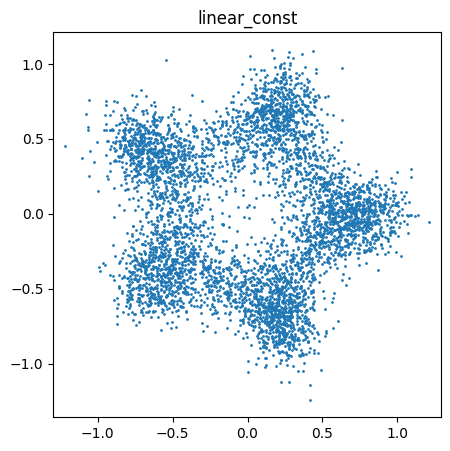


Training linear_linear
Epoch 0: 0.4994
Epoch 100: 0.0683
Epoch 200: 0.0693
Epoch 300: 0.0679
Epoch 400: 0.0698


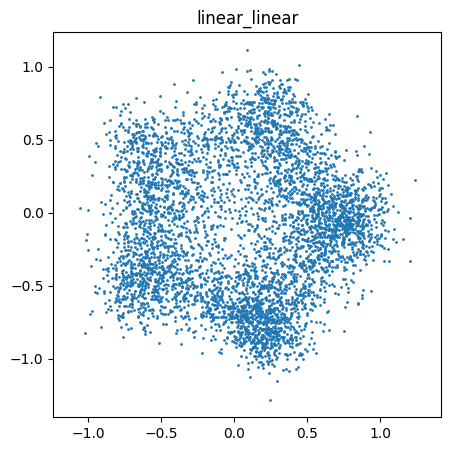


Training linear_exp
Epoch 0: 2.4917
Epoch 100: 0.3754
Epoch 200: 0.3656
Epoch 300: 0.3383
Epoch 400: 0.3550


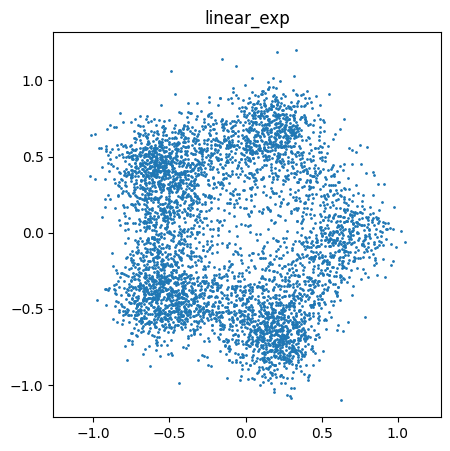


Training cosine_const
Epoch 0: 0.8214
Epoch 100: 0.3151
Epoch 200: 0.3096
Epoch 300: 0.2990
Epoch 400: 0.2956


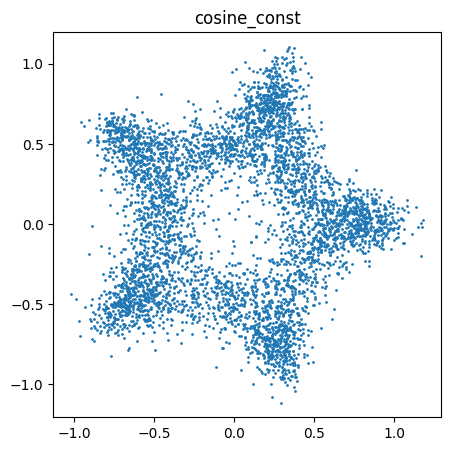


Training cosine_linear
Epoch 0: 0.4755
Epoch 100: 0.1059
Epoch 200: 0.1027
Epoch 300: 0.1006
Epoch 400: 0.1014


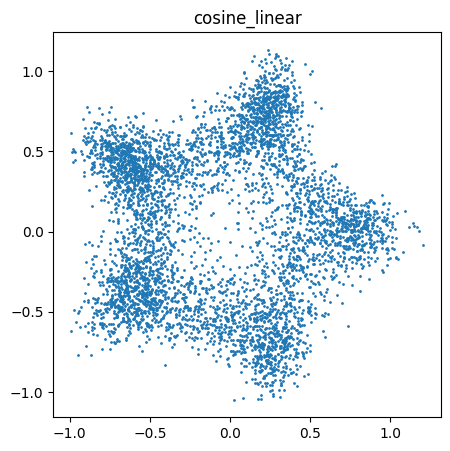


Training cosine_exp
Epoch 0: 2.6508
Epoch 100: 0.5428
Epoch 200: 0.5187
Epoch 300: 0.5299
Epoch 400: 0.4994


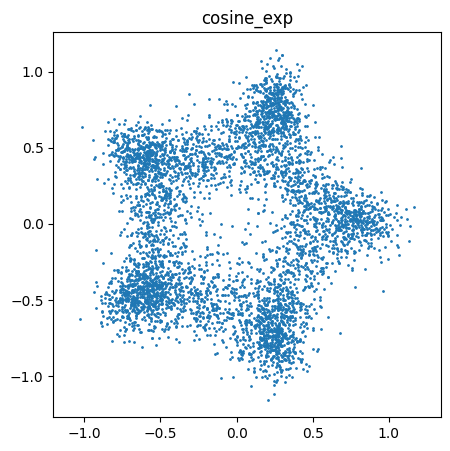


RESULTS:
linear_const (np.float64(0.4182995279338582), np.float64(6.283333333333333), np.float64(1.3323904654430088))
linear_linear (np.float64(0.4481764244773551), np.float64(7.072222222222222), np.float64(1.3616524747498517))
linear_exp (np.float64(0.4393450395496432), np.float64(6.5), np.float64(1.3375170282637145))
cosine_const (np.float64(0.38705995849441815), np.float64(5.711111111111111), np.float64(1.3156182724799623))
cosine_linear (np.float64(0.4152366496980712), np.float64(6.216666666666667), np.float64(1.3276692812941802))
cosine_exp (np.float64(0.3964716351845079), np.float64(5.916666666666667), np.float64(1.314562291625713))


In [22]:
config = Config()
real = generate_star(n_samples=5000)

betas = {
    "linear": beta_linear,
    "cosine": beta_cosine
}

weights = {
    "const": w_const,
    "linear": w_linear,
    "exp": w_exp
}

results = {}

for b_name, b_fn in betas.items():
    for w_name, w_fn in weights.items():
        name = f"{b_name}_{w_name}"

        trainer = VPSDETrainer(config, b_fn, w_fn, name, real)
        trainer.run()

        samples = sample_vp(trainer.model, config, b_fn)

        js, cov, ent = compute_metrics(samples, real)

        results[name] = (js, cov, ent)

        plt.figure(figsize=(5,5))
        plt.scatter(samples[:,0], samples[:,1], s=1)
        plt.title(name)
        plt.axis('equal')
        plt.show()


print("\nRESULTS:")
for k, v in results.items():
    print(k, v)

**Выводы**

**Сравнение расписаний**

Косинусное расписание в среднем показывает лучшее качество генерации (меньше JS divergence: ~$0.38-0.40$ против ~$0.42–0.45$ у линейного).

Визуально форма звезды получается четче.
Это связано с тем, что **cosine schedule**
более плавно добавляет шум, особенно на малых t.

**Перевзвешивание лосса**

- **Constant weight** - даёт стабильное качество, но модель недостаточно фокусируется на поздних шагах.
- **Linear weight** - показывает самую быструю сходимость (наименьший loss), но качество генерации хуже.
- **Exponential weight** - сильно усиливает вклад больших t → обучение становится менее стабильным (высокий стартовый loss).
Качество не улучшается и иногда хуже визуально.

**Итог**

Лучшие результаты достигаются при:

- использовании косинусного расписания
- умеренного перевзвешивания (например, linear)